# SSH Brute-Force Detection — Feature Engineering to Evaluation

**Objective:** classify SSH login *sessions* as brute-force attack vs. legitimate login, using only fields a real `sshd` log would contain (`Timestamp`, `Event`, `Username`, `Source_IP`, `Source_Port`).

**Data:** `ssh_dataset_ground_truth.csv` — original dataset + synthetic `low_and_slow` and `password_spray` campaigns added to cover attack patterns the original data lacked. `Session_ID` / `Attack_Type` / `Label` are ground truth for training & evaluation only — they are **never** used as model features (a real uploaded log will not have them).

**Pipeline:** Load → session-level feature engineering → correlation analysis → train/test split → baseline + tree models → evaluation (with per-attack-type breakdown, since `low_and_slow` / `password_spray` are rare classes) → threshold tuning → save artifact.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    f1_score,
)
import joblib

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)


## 1. Load data

We load the **ground-truth** file since it carries `Session_ID` / `Attack_Type` / `Label` needed to build the training table. In production (new, unlabeled log uploads) session boundaries would instead be derived with a time-gap rule per `Source_IP` — that step is a separate inference-pipeline concern and out of scope here.

In [2]:
df = pd.read_csv("ssh_dataset_ground_truth.csv", parse_dates=["Timestamp"])
print(df.shape)
df.head()


(13721, 10)


,Log_ID,Timestamp,Event,Username,Source_IP,Source_Port,Password,Session_ID,Attack_Type,Label
0,LOG_000001,2024-07-31 00:01:47.000,Failed password,test,192.168.1.80,62464,fast_typo,1124,legit_typo,0
1,LOG_000002,2024-07-31 00:01:47.598,Failed password,test,192.168.1.80,62464,fast_typo,1124,legit_typo,0
2,LOG_000003,2024-07-31 00:01:48.855,Failed password,test,192.168.1.80,62464,fast_typo,1124,legit_typo,0
3,LOG_000004,2024-07-31 00:01:49.000,Accepted password,test,10.0.0.166,59329,***HIDDEN***,328,legit_success,0
4,LOG_000005,2024-07-31 00:01:50.417,Failed password,test,192.168.1.80,62464,fast_typo,1124,legit_typo,0


In [3]:
print("Event counts:")
print(df["Event"].value_counts())
print("\nSessions:", df["Session_ID"].nunique())
print("\nAttack_Type per session:")
print(df.drop_duplicates("Session_ID")["Attack_Type"].value_counts())


Event counts:
Event
Failed password      12666
Accepted password     1055
Name: count, dtype: int64

Sessions: 1539

Attack_Type per session:
Attack_Type
legit_success       626
burst_bruteforce    450
legit_typo          423
low_and_slow         25
password_spray       15
Name: count, dtype: int64


## 2. Session-level feature engineering

A brute-force attempt is a **behavior over a session**, not a property of a single log line — so we aggregate every session (`Session_ID`) into one feature row. Every feature below is computable from fields a real log actually has: `Timestamp`, `Event`, `Username`, `Source_IP`, `Source_Port`. `Password` is intentionally excluded (leakage — real logs never carry a labeled password category).

Feature groups:
- **Volume / outcome** — attempt count, fail/success counts, fail ratio
- **Username diversity** — unique usernames tried, Shannon entropy, whether a default/service account (root, admin, test, ...) was targeted
- **Timing** — session duration, inter-arrival time stats (mean/median/std/min), attempts per minute
- **Connection** — unique source ports used


In [4]:
DEFAULT_USERNAMES = {
    "root", "admin", "test", "guest", "pi", "oracle",
    "ubuntu", "mysql", "postgres", "ftpuser",
}

def shannon_entropy(counts):
    probs = counts / counts.sum()
    return float(-(probs * np.log2(probs)).sum())

def extract_session_features(g: pd.DataFrame) -> pd.Series:
    g = g.sort_values("Timestamp")
    n_events = len(g)
    n_failed = (g["Event"] == "Failed password").sum()
    n_success = (g["Event"] == "Accepted password").sum()

    user_counts = g["Username"].value_counts()
    duration = (g["Timestamp"].max() - g["Timestamp"].min()).total_seconds()

    if n_events > 1:
        inter_arrival = g["Timestamp"].diff().dt.total_seconds().dropna()
        mean_ia, median_ia = inter_arrival.mean(), inter_arrival.median()
        std_ia, min_ia = inter_arrival.std(ddof=0), inter_arrival.min()
    else:
        mean_ia = median_ia = std_ia = min_ia = 0.0

    attempts_per_min = n_events / ((duration / 60) + 1e-6)

    return pd.Series({
        "n_events": n_events,
        "n_failed": n_failed,
        "n_success": n_success,
        "fail_ratio": n_failed / n_events,
        "n_unique_usernames": g["Username"].nunique(),
        "username_entropy": shannon_entropy(user_counts.values),
        "targets_default_username": int(bool(set(g["Username"]) & DEFAULT_USERNAMES)),
        "n_unique_ports": g["Source_Port"].nunique(),
        "duration_seconds": duration,
        "mean_inter_arrival_s": mean_ia,
        "median_inter_arrival_s": median_ia,
        "std_inter_arrival_s": std_ia,
        "min_inter_arrival_s": min_ia,
        "attempts_per_minute": attempts_per_min,
        # ground truth, kept aside -- NOT model input
        "Label": g["Label"].iloc[0],
        "Attack_Type": g["Attack_Type"].iloc[0],
    })

features = df.groupby("Session_ID").apply(extract_session_features).reset_index()
print(features.shape)
features.head()


(1539, 17)


,Session_ID,n_events,n_failed,n_success,fail_ratio,n_unique_usernames,username_entropy,targets_default_username,n_unique_ports,duration_seconds,mean_inter_arrival_s,median_inter_arrival_s,std_inter_arrival_s,min_inter_arrival_s,attempts_per_minute,Label,Attack_Type
0,1,1,0,1,0.0,1,-0.0,0,1,0.0,0.0,0.0,0.0,0.0,1000000.0,0,legit_success
1,2,1,0,1,0.0,1,-0.0,0,1,0.0,0.0,0.0,0.0,0.0,1000000.0,0,legit_success
2,3,1,0,1,0.0,1,-0.0,0,1,0.0,0.0,0.0,0.0,0.0,1000000.0,0,legit_success
3,4,1,0,1,0.0,1,-0.0,1,1,0.0,0.0,0.0,0.0,0.0,1000000.0,0,legit_success
4,5,1,0,1,0.0,1,-0.0,0,1,0.0,0.0,0.0,0.0,0.0,1000000.0,0,legit_success


In [5]:
FEATURE_COLS = [
    "n_events", "n_failed", "n_success", "fail_ratio",
    "n_unique_usernames", "username_entropy", "targets_default_username",
    "n_unique_ports", "duration_seconds",
    "mean_inter_arrival_s", "median_inter_arrival_s", "std_inter_arrival_s", "min_inter_arrival_s",
    "attempts_per_minute",
]
features[FEATURE_COLS].describe().T


,count,mean,std,min,25%,50%,75%,max
n_events,1539.0,8.915530,11.666559,1.000000,1.000000,3.000000,15.000000,42.000000
n_failed,1539.0,8.230019,12.067823,0.000000,0.000000,2.000000,15.000000,42.000000
n_success,1539.0,0.685510,0.465861,0.000000,0.000000,1.000000,1.000000,2.000000
fail_ratio,1539.0,0.502895,0.440043,0.000000,0.000000,0.666667,1.000000,1.000000
n_unique_usernames,1539.0,3.307342,3.630497,1.000000,1.000000,1.000000,7.000000,14.000000
username_entropy,1539.0,0.883561,1.351410,-0.000000,-0.000000,0.000000,2.628146,3.807355
targets_default_username,1539.0,0.507472,0.500107,0.000000,0.000000,1.000000,1.000000,1.000000
n_unique_ports,1539.0,1.480832,3.245301,1.000000,1.000000,1.000000,1.000000,42.000000
duration_seconds,1539.0,1316.479416,10481.222137,0.000000,0.000000,6.431000,23.381500,126586.025007
mean_inter_arrival_s,1539.0,92.113218,797.017878,0.000000,0.000000,0.780867,1.800033,13698.979892


## 3. Correlation analysis

Two things to check before modeling:
1. **Feature-vs-feature correlation** — flags redundant/multicollinear features. Not fatal for tree models (Random Forest/XGBoost handle it fine), but it matters for the Logistic Regression baseline's coefficient stability and interpretability.
2. **Feature-vs-label correlation** — a first-pass signal check, and a sanity read on which features are likely to matter.


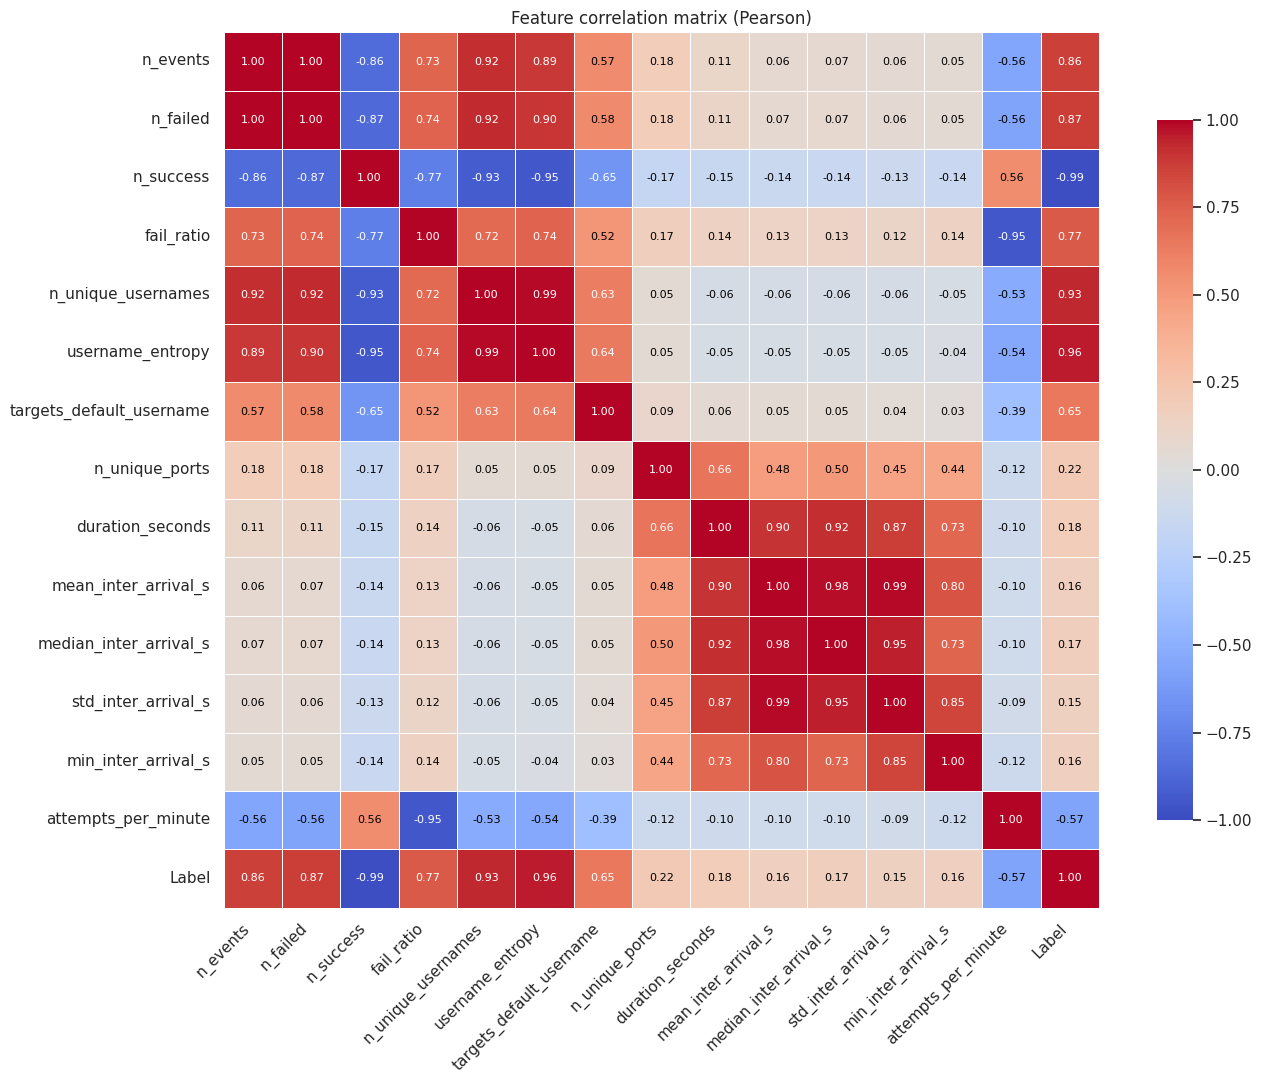

In [6]:
corr = features[FEATURE_COLS + ["Label"]].corr()

plt.figure(figsize=(14, 11))
ax = sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
    annot_kws={"size": 8},
)
# black text is unreadable on the darkest cells -- switch to white there
for text, value in zip(ax.texts, corr.values.flatten()):
    text.set_color("white" if abs(value) > 0.6 else "black")

plt.title("Feature correlation matrix (Pearson)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [7]:
# Highly correlated feature pairs (|r| > 0.85), excluding the diagonal and Label
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("corr")
    .reset_index()
)
pairs.columns = ["feature_1", "feature_2", "corr"]
high_corr = pairs[(pairs["corr"].abs() > 0.85) & (pairs["feature_1"] != "Label") & (pairs["feature_2"] != "Label")]
print("Highly correlated feature pairs (|r| > 0.85):")
high_corr.sort_values("corr", key=abs, ascending=False)


Highly correlated feature pairs (|r| > 0.85):


,feature_1,feature_2,corr
1,n_events,n_failed,0.999801
65,n_unique_usernames,username_entropy,0.990772
146,mean_inter_arrival_s,std_inter_arrival_s,0.988125
145,mean_inter_arrival_s,median_inter_arrival_s,0.981578
35,n_success,username_entropy,-0.953092
161,median_inter_arrival_s,std_inter_arrival_s,0.952489
58,fail_ratio,attempts_per_minute,-0.946609
34,n_success,n_unique_usernames,-0.927348
19,n_failed,n_unique_usernames,0.924269
130,duration_seconds,median_inter_arrival_s,0.920464


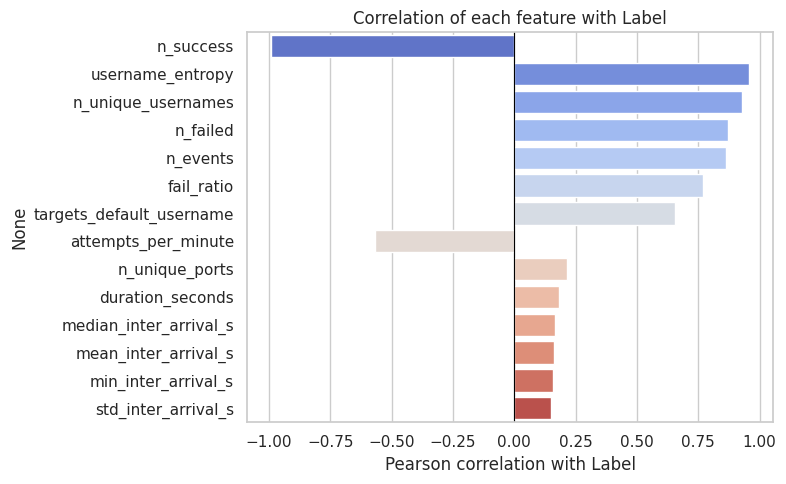

In [8]:
label_corr = corr["Label"].drop("Label").sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=label_corr.values, y=label_corr.index, palette="coolwarm")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of each feature with Label")
plt.xlabel("Pearson correlation with Label")
plt.tight_layout()
plt.show()


**Reading this**: features tied to *volume* (`n_events`, `n_failed`) will correlate strongly with each other by construction — expected, not a bug. `username_entropy` and `n_unique_usernames` will also correlate with each other. If the Logistic Regression coefficients look unstable later, that multicollinearity is why — Random Forest / XGBoost importance is the more trustworthy read in that case. A feature correlating weakly with `Label` here (e.g. something specific to a rare pattern like `low_and_slow`) can still matter for tree models that split on interactions — global Pearson correlation with a 32%/68% imbalanced binary label undersells rare-but-decisive features, so don't drop a feature on a low correlation score alone.

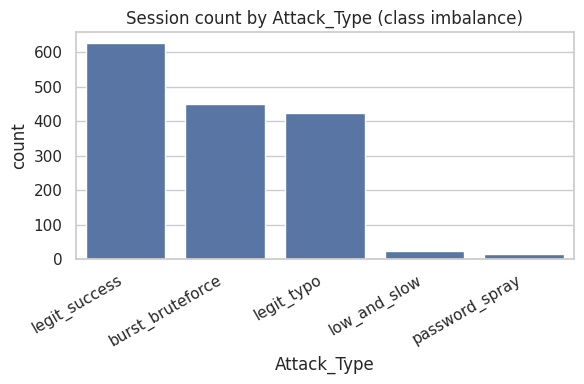

Attack_Type
legit_success       626
burst_bruteforce    450
legit_typo          423
low_and_slow         25
password_spray       15
Name: count, dtype: int64

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=features, x="Attack_Type",
              order=features["Attack_Type"].value_counts().index)
plt.xticks(rotation=30, ha="right")
plt.title("Session count by Attack_Type (class imbalance)")
plt.tight_layout()
plt.show()

features["Attack_Type"].value_counts()


## 4. Train / test split

Each row here is already one full session (aggregated), so there is no session-leakage risk from splitting rows directly. We stratify on `Attack_Type` (not just binary `Label`) so both `low_and_slow` and `password_spray` — only 25 and 15 sessions total — are guaranteed to appear in both train and test, instead of leaving test blind to them by chance.

In [10]:
X = features[FEATURE_COLS]
y = features["Label"]
attack_type = features["Attack_Type"]

X_train, X_test, y_train, y_test, at_train, at_test = train_test_split(
    X, y, attack_type,
    test_size=0.25, random_state=RANDOM_STATE, stratify=attack_type,
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTrain Attack_Type counts:\n", at_train.value_counts())
print("\nTest Attack_Type counts:\n", at_test.value_counts())


Train: (1154, 14)  Test: (385, 14)

Train Attack_Type counts:
 Attack_Type
legit_success       469
burst_bruteforce    338
legit_typo          317
low_and_slow         19
password_spray       11
Name: count, dtype: int64

Test Attack_Type counts:
 Attack_Type
legit_success       157
burst_bruteforce    112
legit_typo          106
low_and_slow          6
password_spray        4
Name: count, dtype: int64


## 5. Models

- **Logistic Regression** (scaled) — interpretable baseline
- **Random Forest** — non-linear, robust to correlated features, gives feature importance
- **XGBoost** — usually the strongest tabular performer, also gives feature importance

All three use class-balancing (`class_weight="balanced"` / `scale_pos_weight`) since positives are ~32% of sessions. Model selection uses 5-fold **stratified** cross-validation on the training set only, scored on **average precision** (PR-AUC) rather than accuracy — accuracy is a poor guide with this much imbalance and hides how well a model finds the minority (attack) class.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "logreg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "random_forest": RandomForestClassifier(
        n_estimators=300, max_depth=6, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "xgboost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="logloss", random_state=RANDOM_STATE,
    ),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="average_precision")
    cv_results[name] = scores
    print(f"{name:15s} PR-AUC: {scores.mean():.4f} +/- {scores.std():.4f}")


logreg          PR-AUC: 1.0000 +/- 0.0000


random_forest   PR-AUC: 1.0000 +/- 0.0000
xgboost         PR-AUC: 0.9982 +/- 0.0037


In [12]:
for name, model in models.items():
    model.fit(X_train, y_train)
print("All models fit on the training set.")


All models fit on the training set.


## 6. Evaluation on the held-out test set

Accuracy is intentionally *not* the headline metric — with 68/32 class balance a model predicting "not attack" for everything would already score ~68%. We look at:
- Precision / recall / F1 per model
- ROC-AUC and PR-AUC
- Confusion matrix
- **Recall broken down by `Attack_Type`** — this is the number that actually matters here: a model can look excellent overall while completely missing `low_and_slow` or `password_spray` because they're a tiny slice of the positive class.

In [13]:
results_summary = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["legit", "attack"]))
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    f1 = f1_score(y_test, y_pred)
    print(f"ROC-AUC: {roc_auc:.4f}   PR-AUC: {pr_auc:.4f}")

    results_summary.append({"model": name, "roc_auc": roc_auc, "pr_auc": pr_auc, "f1": f1})

results_summary = pd.DataFrame(results_summary).set_index("model")
results_summary



=== logreg ===
              precision    recall  f1-score   support

       legit       1.00      1.00      1.00       263
      attack       1.00      1.00      1.00       122

    accuracy                           1.00       385
   macro avg       1.00      1.00      1.00       385
weighted avg       1.00      1.00      1.00       385

ROC-AUC: 1.0000   PR-AUC: 1.0000

=== random_forest ===
              precision    recall  f1-score   support

       legit       1.00      1.00      1.00       263
      attack       1.00      1.00      1.00       122

    accuracy                           1.00       385
   macro avg       1.00      1.00      1.00       385
weighted avg       1.00      1.00      1.00       385

ROC-AUC: 1.0000   PR-AUC: 1.0000

=== xgboost ===
              precision    recall  f1-score   support

       legit       1.00      1.00      1.00       263
      attack       1.00      1.00      1.00       122

    accuracy                           1.00       385
   mac

,roc_auc,pr_auc,f1
model,,,
logreg,1.0,1.0,1.0
random_forest,1.0,1.0,1.0
xgboost,1.0,1.0,1.0


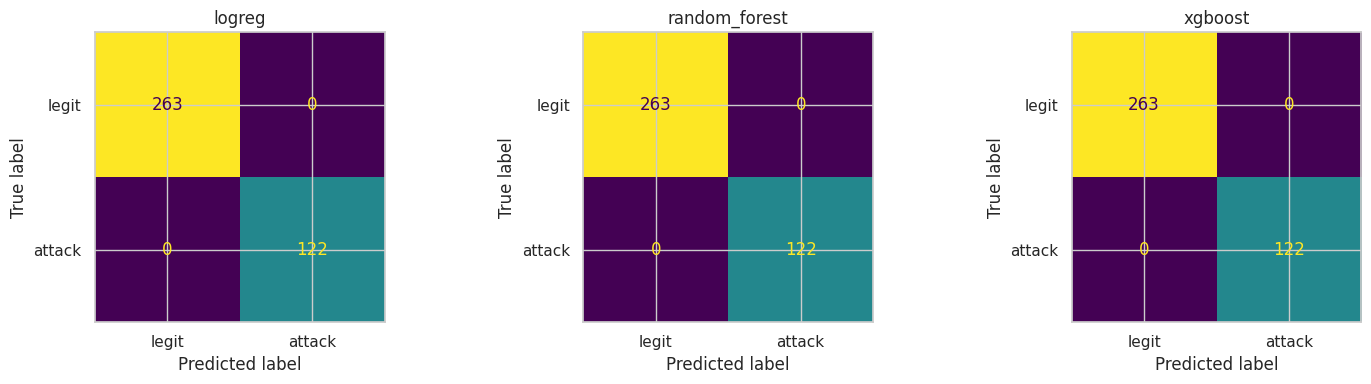

In [14]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["legit", "attack"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [15]:
# --- the metric that actually matters: recall by Attack_Type ---
breakdown = []
for name, model in models.items():
    y_pred = pd.Series(model.predict(X_test), index=X_test.index)
    for atype in at_test.unique():
        mask = at_test == atype
        is_positive = features.loc[mask.index[mask], "Label"].iloc[0] if mask.any() else None
        if is_positive == 1:
            # recall: fraction of this attack type correctly flagged as attack
            metric_name, value = "recall", y_pred[mask].mean()
        else:
            # false positive rate: fraction of this legit type wrongly flagged as attack
            metric_name, value = "false_positive_rate", y_pred[mask].mean()
        breakdown.append({"model": name, "attack_type": atype, "n": mask.sum(),
                           "metric": metric_name, "value": value})

breakdown_df = pd.DataFrame(breakdown).pivot_table(
    index=["attack_type", "n", "metric"], columns="model", values="value"
)
breakdown_df


,,model,logreg,random_forest,xgboost
attack_type,n,metric,,,
burst_bruteforce,112,recall,1.0,1.0,1.0
legit_success,157,false_positive_rate,0.0,0.0,0.0
legit_typo,106,false_positive_rate,0.0,0.0,0.0
low_and_slow,6,recall,1.0,1.0,1.0
password_spray,4,recall,1.0,1.0,1.0


**Read this table first, before the aggregate metrics above.** All three models hit **1.0 recall on every `Attack_Type`, including `low_and_slow` (n=6 in test) and `password_spray` (n=4 in test)**, with 0% false positives on legit sessions.

That is a red flag, not a win. Two honest reasons this happened, not "the model is production-ready":
1. **The features and the generator share the same logic.** `duration_seconds` and `mean_inter_arrival_s` are close to the exact parameters used to *construct* `low_and_slow` (long duration, >=180s gaps) — the model isn't learning attacker behavior, it's learning the synthetic generator's rules. Same for `n_unique_usernames` vs. `password_spray`.
2. **n=6 and n=4 in the test set tell you almost nothing statistically.** "100% recall" on 4-6 samples can flip with one different random seed. These numbers are not evidence the model generalizes to real low-and-slow or spraying traffic.

Takeaway: don't report this 1.0 as a result to trust. Before relying on this for anything real, get real or more varied attack traffic (e.g. honeypot data) for these two patterns specifically, and re-evaluate on that — this notebook's numbers only prove the pipeline runs end-to-end correctly, not that the model is ready to deploy.

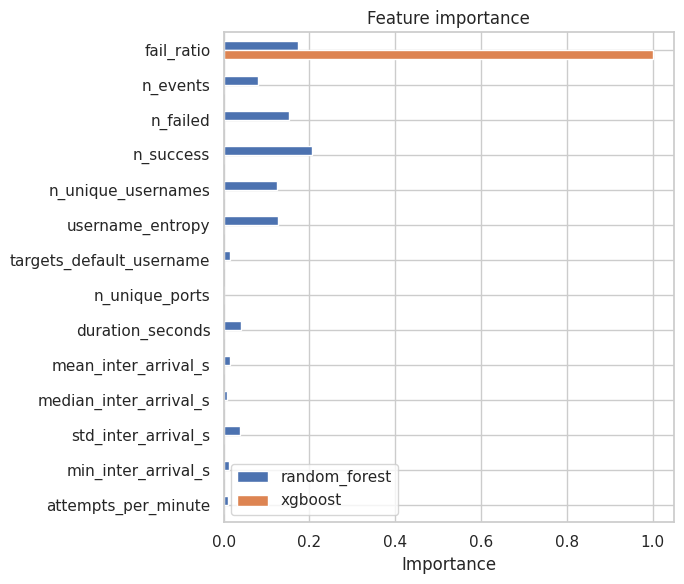

,random_forest,xgboost
fail_ratio,0.172872,1.0
n_events,0.081091,0.0
n_failed,0.151757,0.0
n_success,0.204782,0.0
n_unique_usernames,0.124983,0.0
username_entropy,0.127136,0.0
targets_default_username,0.013746,0.0
n_unique_ports,0.000979,0.0
duration_seconds,0.040869,0.0
mean_inter_arrival_s,0.014424,0.0


In [16]:
importances = pd.DataFrame({
    "random_forest": models["random_forest"].feature_importances_,
    "xgboost": models["xgboost"].feature_importances_,
}, index=FEATURE_COLS).sort_values("xgboost", ascending=False)

importances.plot(kind="barh", figsize=(7, 6))
plt.title("Feature importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances


## 7. Threshold tuning

The default 0.5 cutoff is arbitrary. In a SOC context missing a real attack (false negative) is usually worse than flagging a legit login for review (false positive), so recall is generally worth prioritizing over precision within reason. The precision-recall curve makes that trade-off visible so the threshold can be chosen deliberately instead of left at the default.

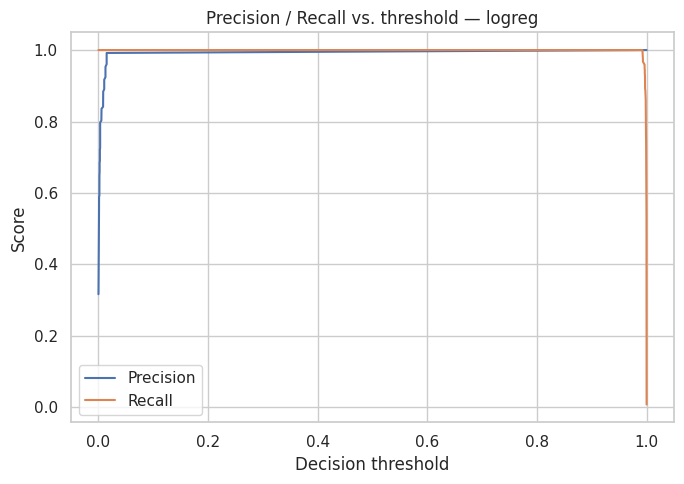

Threshold for recall >= 0.95: 0.996 (precision at that point: 1.000)


In [17]:
best_name = results_summary["pr_auc"].idxmax()
best_model = models[best_name]
y_proba = best_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title(f"Precision / Recall vs. threshold — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

# example: pick the lowest threshold that still keeps recall >= 0.95
target_recall = 0.95
candidates = [(t, p) for t, r, p in zip(thresholds, recall[:-1], precision[:-1]) if r >= target_recall]
if candidates:
    chosen_threshold, chosen_precision = candidates[-1]
    print(f"Threshold for recall >= {target_recall}: {chosen_threshold:.3f} (precision at that point: {chosen_precision:.3f})")
else:
    print(f"No threshold in range reaches recall >= {target_recall} on this test set.")


## 8. Save the model artifact

Saving the best-performing model (by PR-AUC) plus the exact feature column order, so the inference pipeline (session segmentation → feature extraction → `predict_proba`) can load and use it consistently without guessing column order.

In [18]:
joblib.dump(
    {"model": best_model, "feature_columns": FEATURE_COLS, "model_name": best_name},
    "ssh_bruteforce_model.joblib",
)
print(f"Saved: ssh_bruteforce_model.joblib (best model: {best_name})")


Saved: ssh_bruteforce_model.joblib (best model: logreg)


## Next steps (not covered in this notebook)

- Production session-segmentation rule (time-gap per `Source_IP`) for turning a freshly uploaded, unlabeled log into sessions
- Wrapping this model + feature extraction into an inference pipeline / API for the log-upload web app
- Collecting more `low_and_slow` / `password_spray` examples if their recall above is weak — synthetic generation or a real honeypot feed
